# Multiscale Modeling of Biological Systems: Neuroscience - Assignment


## Setup

Follow instructions in `README.md` and import needed files


In [19]:
import rsatoolbox as rsa
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
print(matplotlib.get_backend())

from core import SantoroDataset, MODEL_CLASSES, extract_activations

from torch.utils.data import DataLoader
from torch import Tensor


module://matplotlib_inline.backend_inline


## Part I


In [20]:
dataset = SantoroDataset()

categories = set(dataset.categories)

print(f"Unique Categories ({len(categories)}):", categories)
print("Models:", ", ".join(MODEL_CLASSES.keys()))

Unique Categories (73): {'paper', 'baby', 'rain', 'thunder', 'bagpipe', 'waterfall', 'dice', 'zipper', 'water', 'hairdryer', 'guitar', 'metal', 'cat', 'glass', 'clarinet', 'river', 'motor', 'keys', 'percussion', 'bass', 'brush', 'synthesizer', 'wolf', 'firework', 'bells', 'wind', 'bell', 'harp', 'sawing', 'wood', 'cutting', 'organ', 'sitar', 'woman', 'flute', 'pig', 'toothbrush', 'bird', 'duck', 'insect', 'chimes', 'hammer', 'horn', 'drum', 'sheep', 'monkey', 'ensamble', 'waves', 'siren', 'violin', 'car', 'piano', 'bottle', 'clock', 'trumpet', 'elastic', 'dishes', 'phone', 'man', 'cow', 'horse', 'gun', 'chicken', 'door', 'ocean', 'whistle', 'typewriter', 'toilet', 'dog', 'goat', 'engine', 'accordion', 'harmonica'}
Models: waveform, uninspired, inspired


### Brain responses data

- columns = features gathered from the STG.
- rows = each category (e.g. bird sound).


In [21]:
# Create rsatoolbox dataset:
def calculate_rdm(tensor: Tensor):
    rsa_data = rsa.data.Dataset(
        tensor.detach().cpu().reshape(tensor.shape[0], -1).numpy() 
    )

    return rsa.rdm.calc_rdm(rsa_data, method='correlation')


# Fix just in case it does not show up on its own
def show_rdm(rdm, **kwargs):
    fig, axes, handles = rsa.vis.show_rdm(rdm_stg, **kwargs)
    plt.show()

### 1. RDMs


#### a) STG brain data


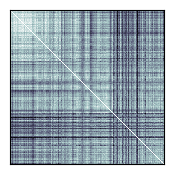

In [22]:
rdm_stg = calculate_rdm(dataset.brain_responses)

show_rdm(rdm_stg)

#### b) each layer of the three provided untrained models


waveform


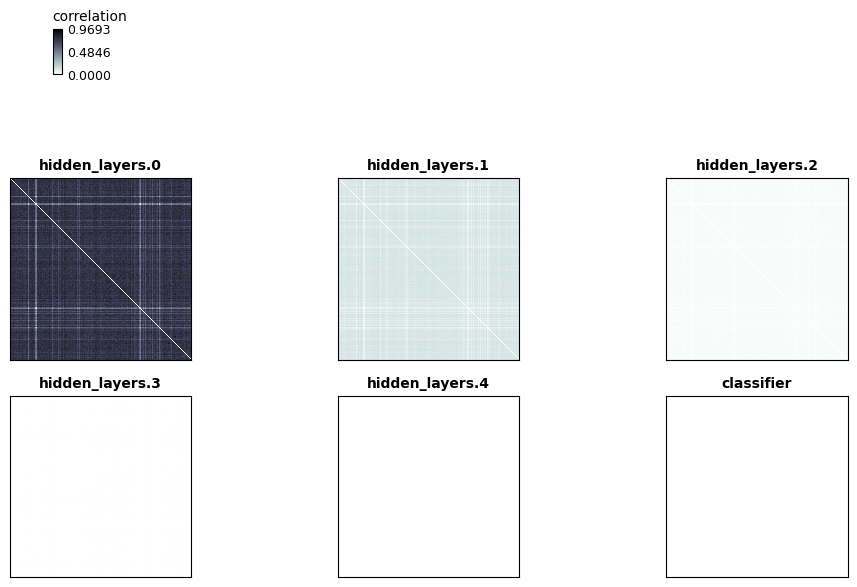

uninspired


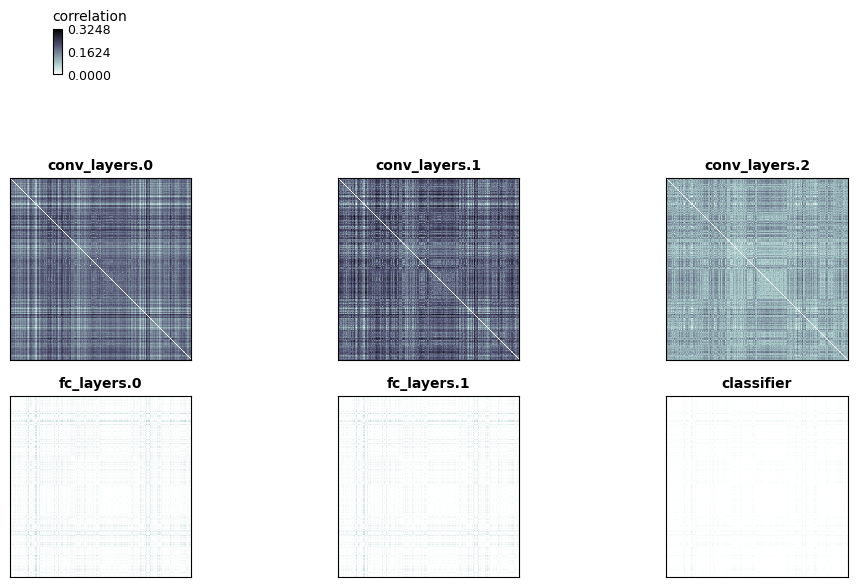

inspired


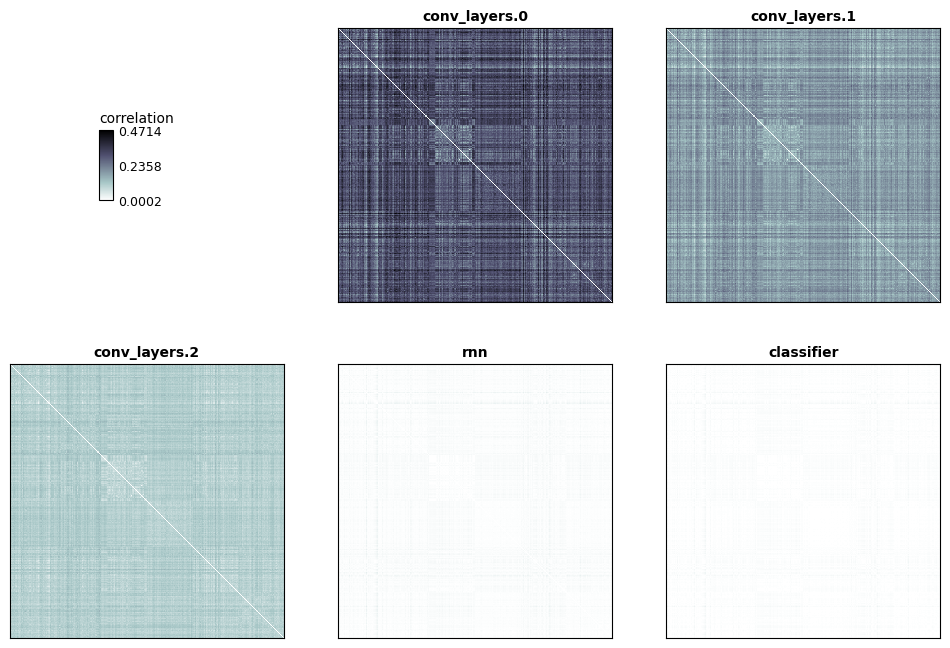

In [23]:
for model_name, ModelClass in MODEL_CLASSES.items():
    print(model_name)
    
    model = ModelClass(num_classes=50)

    loader = DataLoader(dataset, batch_size=16, shuffle=False)

    activations = extract_activations(loader, model)

    untrained_rdms = {}

    for layer_name, layer_act in activations.items():
        untrained_rdms[layer_name] = calculate_rdm(layer_act)

    layer_names = list(untrained_rdms)

    all_rdms = rsa.rdm.concat(
        *(untrained_rdms[name] for name in layer_names)
    )

    all_rdms.rdm_descriptors["layer"] = layer_names

    fig, axes, handles = rsa.vis.show_rdm(
        all_rdms,
        rdm_descriptor="layer",
        n_column=3,
        show_colorbar="figure",  # shared scale across panels
        figsize=(12, 8),
    )

    plt.show()

#### c) each layer of the three provided trained models

Load the best model from each training run and calculate the RDMs using the same sound order as the brain data. Keep each run separate so we can compare them later. Below, we show the first run of each model type.

Like before, `extract_activations` treats the GRU as one `rnn` layer. It only uses the output of the last GRU layer, instead of looking at the two GRU layers separately.

waveform, run0: 6 layer RDMs
waveform, run1: 6 layer RDMs
waveform, run2: 6 layer RDMs
waveform, run3: 6 layer RDMs
waveform, run4: 6 layer RDMs


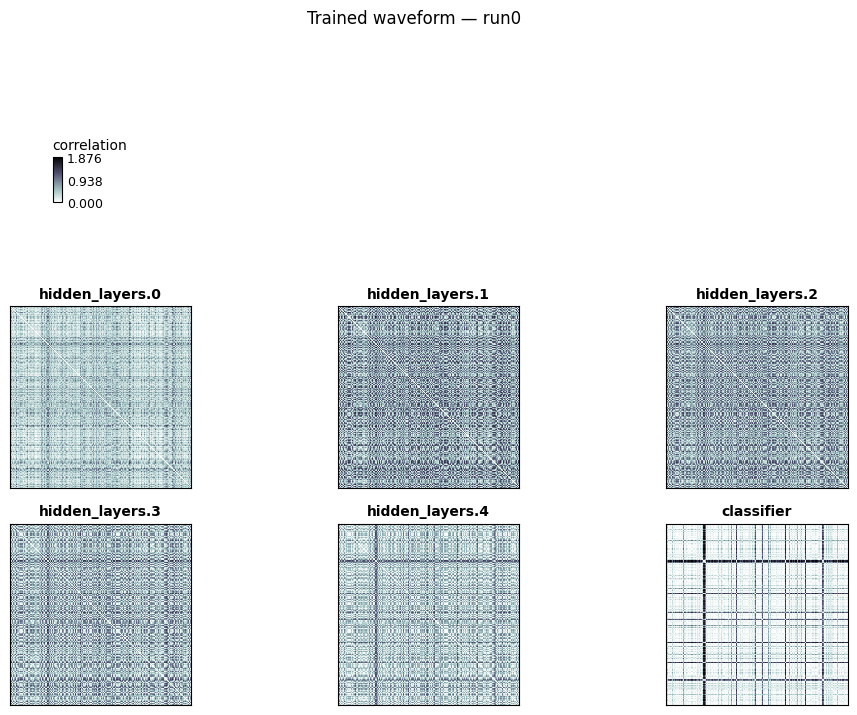

uninspired, run0: 6 layer RDMs
uninspired, run1: 6 layer RDMs
uninspired, run2: 6 layer RDMs
uninspired, run3: 6 layer RDMs
uninspired, run4: 6 layer RDMs


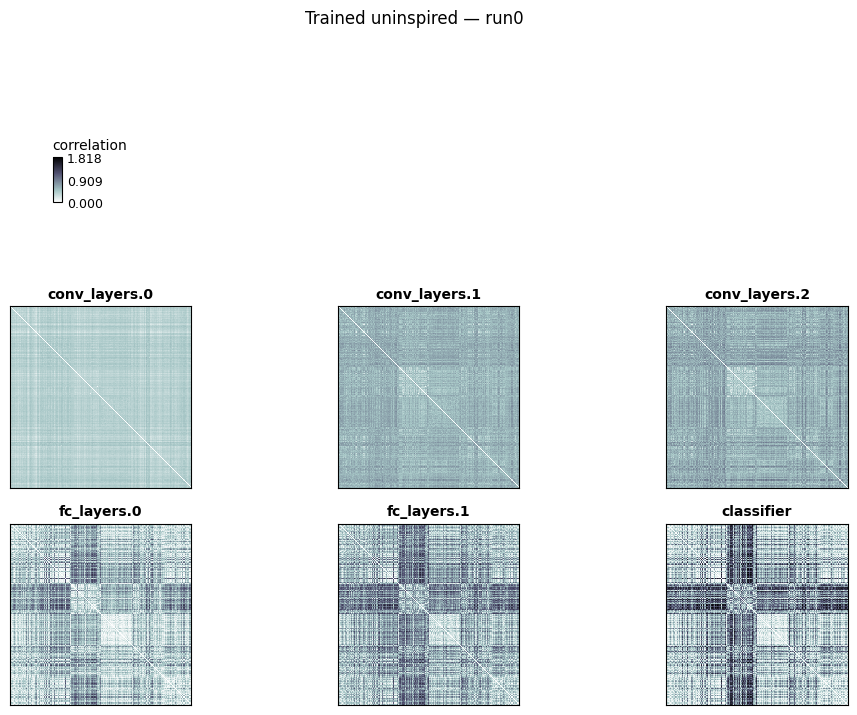

inspired, run0: 5 layer RDMs
inspired, run1: 5 layer RDMs
inspired, run2: 5 layer RDMs
inspired, run3: 5 layer RDMs
inspired, run4: 5 layer RDMs


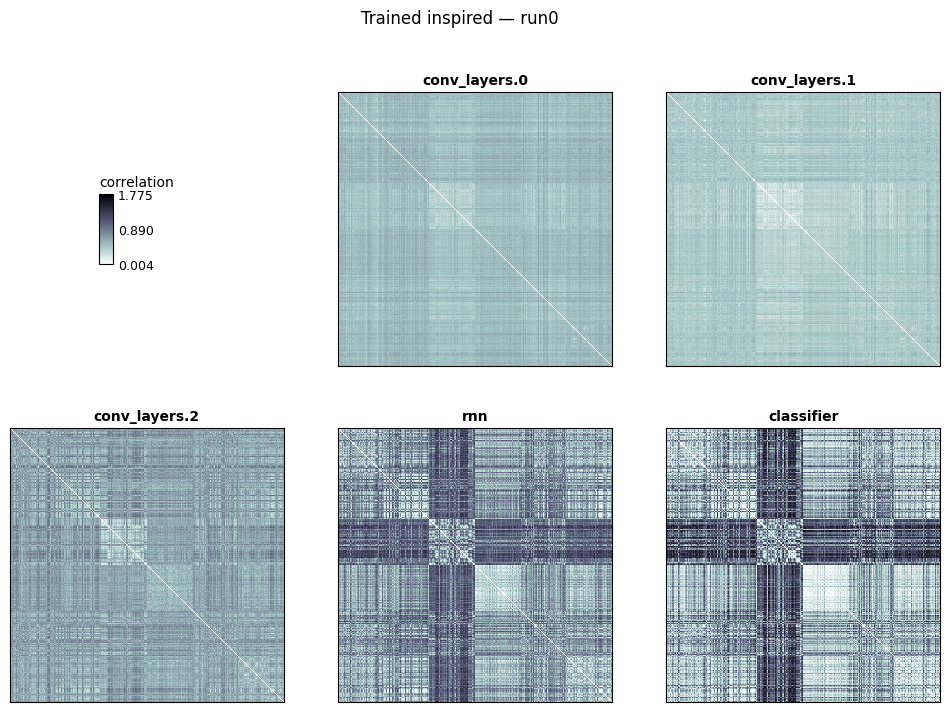

In [24]:
from pathlib import Path
import torch
import core

models_dir = Path(core.__file__).resolve().parent / 'models'
loader = DataLoader(dataset, batch_size=16, shuffle=False)

# trained_rdms[model_name][run_name][layer_name]
trained_rdms = {}

for model_name, ModelClass in MODEL_CLASSES.items():
    checkpoints = sorted(models_dir.glob(f'{model_name}_run*_best.pt'))
    if not checkpoints:
        raise FileNotFoundError(f'No trained checkpoints for {model_name} in {models_dir}')

    trained_rdms[model_name] = {}
    for checkpoint_path in checkpoints:
        run_name = checkpoint_path.stem.removeprefix(f'{model_name}_').removesuffix('_best')
        model = ModelClass(num_classes=50)
        state_dict = torch.load(checkpoint_path, map_location='cpu', weights_only=True)
        model.load_state_dict(state_dict)
        model.eval()

        activations = extract_activations(loader, model)
        trained_rdms[model_name][run_name] = {
            layer_name: calculate_rdm(layer_act)
            for layer_name, layer_act in activations.items()
        }
        print(f'{model_name}, {run_name}: {len(activations)} layer RDMs')
        del activations, model, state_dict

    # Display one run per architecture; all runs remain available above.
    first_run = next(iter(trained_rdms[model_name]))
    layer_rdms = trained_rdms[model_name][first_run]
    all_rdms = rsa.rdm.concat(*layer_rdms.values())
    all_rdms.rdm_descriptors['layer'] = list(layer_rdms)
    fig, axes, handles = rsa.vis.show_rdm(
        all_rdms,
        rdm_descriptor='layer',
        n_column=3,
        show_colorbar='figure',
        figsize=(12, 8),
    )
    fig.suptitle(f'Trained {model_name} — {first_run}')
    plt.show()


#### d) the embeddings extracted from the pretrained YAMNet model given in `data/yamnet_embeddings/`

YAMNet embeddings shape: (288, 1024)


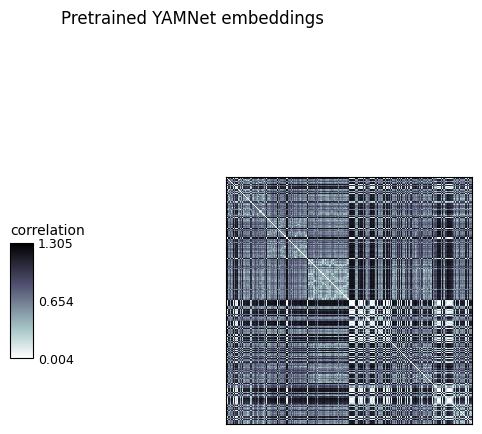

In [25]:
from core import load_yamnet_activations
import torch

# Rows follow the same sound order as SantoroDataset.
yamnet_activations = load_yamnet_activations(layer="embedding")
yamnet_embeddings = torch.as_tensor(yamnet_activations["embedding"])

print("YAMNet embeddings shape:", tuple(yamnet_embeddings.shape))

rdm_yamnet = calculate_rdm(yamnet_embeddings)

fig, axes, handles = rsa.vis.show_rdm(
    rdm_yamnet,
    show_colorbar="figure",
    figsize=(7, 6),
)
fig.suptitle("Pretrained YAMNet embeddings")
plt.show()

### 2. Compare the models to the brain data and conduct an analysis 

#### a) the effect of training on brain alignment, comparing the untrained to the trained models

#### b) the effect of architectural choices on brain alignment

#### c) how well layers at different depths of the models align with brain data of the STG